In [3]:
# Remove #, if only needed
import sys
#!{sys.executable} -m pip install scikit-optimize
#!{sys.executable} -m pip install xlrd
#!pip install scikit-optimize

In [1]:
# ---------- Step 0: Importing Packages ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import RFE
from skopt import BayesSearchCV
from skopt.space import Real
import warnings
warnings.filterwarnings('ignore')



In [2]:
# ---------- Step 1: Load Excel ----------
file_path = "walmart-sales-dataset-of-45stores.csv"  # <-- Change this to your actual file
df = pd.read_csv (file_path)

In [4]:
# ---------- Step 2: Handle Missing Values ----------
# Separate numeric and non-numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
non_numeric_cols = df.select_dtypes(exclude=['number']).columns

# Apply mean imputation only to numeric columns
if len(numeric_cols) > 0:
    numeric_imputer = SimpleImputer(strategy='mean')
    df[numeric_cols] = numeric_imputer.fit_transform(df[numeric_cols])

# Apply most frequent imputation to non-numeric columns
if len(non_numeric_cols) > 0:
    non_numeric_imputer = SimpleImputer(strategy='most_frequent')
    df[non_numeric_cols] = non_numeric_imputer.fit_transform(df[non_numeric_cols])

In [5]:
# ---------- Step 3: Remove Duplicates ----------
df.drop_duplicates(inplace=True)

In [6]:
# ---------- Step 4: Encode Categorical Variables ----------
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
# ---------- Step 5: Normalize Features ----------
scaler = MinMaxScaler()
df[df.columns] = scaler.fit_transform(df)

In [8]:
# ---------- Step 6: Define Features and Target ----------
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [9]:
# ---------- Step 7: Feature Selection via RFE ----------
estimator = Lasso(alpha=0.01, max_iter=10000)
rfe = RFE(estimator, n_features_to_select=int(X.shape[1] * 0.8))  # Keep top 80% features
X_rfe = rfe.fit_transform(X, y)
selected_features = X.columns[rfe.support_]
print(f"Selected Features: {list(selected_features)}")

Selected Features: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI']


In [10]:
# ---------- Step 8: Split Dataset ----------
X_train_val, X_test, y_train_val, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

In [11]:
# ---------- Step 9: Train with Lasso ----------
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train, y_train)

Lasso(alpha=0.01, max_iter=10000)

In [12]:
# ---------- Step 10: Evaluation and Parity Plot ----------
def evaluate(model, X, y, label="Dataset", show_plot=False):
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    print(f"\n{label} Metrics:")
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    
    if show_plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y, y_pred, alpha=0.7, edgecolors='k')
        plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2)
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.title(f"Parity Plot: {label}")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    return r2, mse, rmse, mae


Training Metrics:
R²: 0.0775
MSE: 0.0298
RMSE: 0.1728
MAE: 0.1186


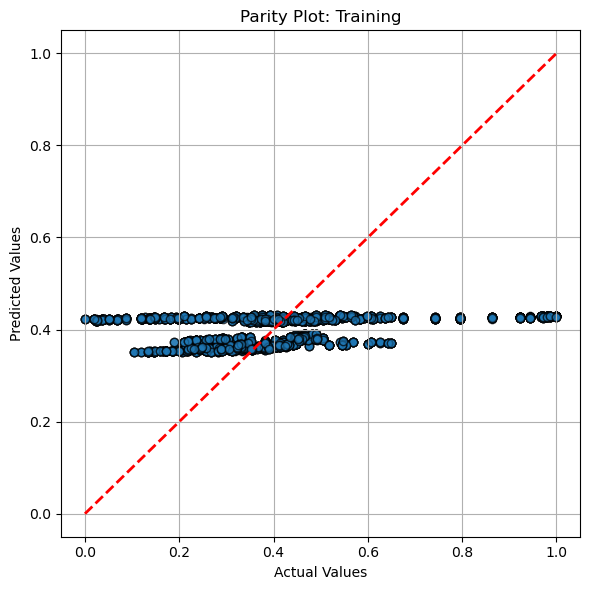


Validation Metrics:
R²: 0.0639
MSE: 0.0298
RMSE: 0.1726
MAE: 0.1186


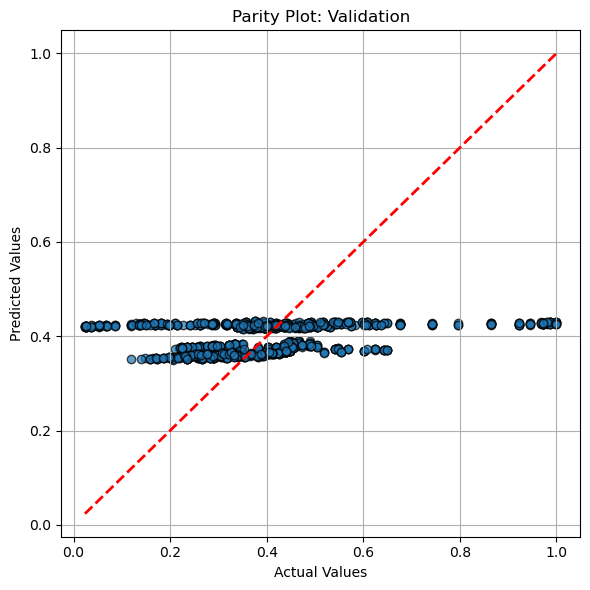

(0.06390042143332886,
 0.02979895994569142,
 np.float64(0.1726237525536142),
 0.11862034204218663)

In [13]:
# ---------- Step 11: Evaluate Training and Validation ----------
evaluate(lasso, X_train, y_train, "Training", show_plot=True)
evaluate(lasso, X_val, y_val, "Validation", show_plot=True)

In [14]:
# ---------- Step 12: Hyperparameter Tuning with Bayesian Optimization ----------
param_space = {
    'alpha': Real(1e-4, 1.0, prior='log-uniform')
}
opt = BayesSearchCV(
    estimator=Lasso(max_iter=10000),
    search_spaces=param_space,
    n_iter=30,
    cv=3,
    scoring='r2',
    random_state=42
)
opt.fit(X_train, y_train)

print(f"\nBest alpha from Bayesian Optimization: {opt.best_params_['alpha']:.6f}")


Best alpha from Bayesian Optimization: 0.000135



Test Metrics:
R²: 0.1656
MSE: 0.0273
RMSE: 0.1652
MAE: 0.1086


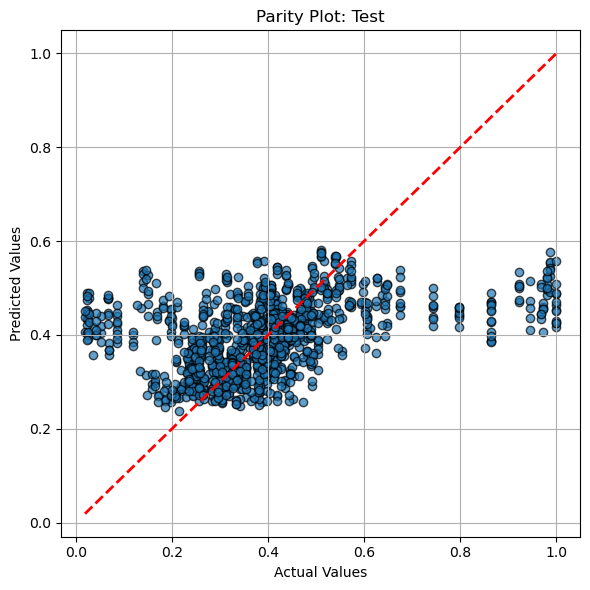

(0.1655627660432093,
 0.027279622851412406,
 np.float64(0.16516544085071916),
 0.10856797953865101)

In [15]:
# ---------- Step 13: Final Evaluation on Test Set ----------
best_model = opt.best_estimator_
evaluate(best_model, X_test, y_test, "Test", show_plot=True)